<a href="https://colab.research.google.com/github/Pranav03125/LaundryWateWaterTreatment_ML/blob/main/laundryWateWaterTreatment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import numpy as np
import pandas as pd

file_path = "/content/COMPLETE DATA.xlsx"

def load_and_check_sheet(sheet_name, expected_cols=None, header=0, skiprows=None):
    # Load sheet with specified header and skiprows
    df = pd.read_excel(file_path, sheet_name=sheet_name, header=header, skiprows=skiprows)
    print(f"\nLoaded sheet '{sheet_name}' columns:")
    print(df.columns.tolist())
    if expected_cols:
        # Filter columns by intersection with expected_cols
        present_cols = [col for col in expected_cols if col in df.columns]
        if not present_cols:
            print(f"Warning: None of the expected columns found in sheet '{sheet_name}'")
            return pd.DataFrame()  # return empty df to prevent error
        else:
            print(f"Using columns from '{sheet_name}': {present_cols}")
            return df[present_cols].dropna(how='all')
    return df

# Define expected columns for sheets based on your Excel contents:

chito_rapid_cols = ['Rapid mixing rate (rpm)', 'Colour removal (%)', 'Turbidity removal (%)']
chito_slow_cols = ['Slow mixing rate (rpm)', 'Colour removal (%)', 'Turbidity removal (%)']
chito_time_cols = ['Rapid mixing time (min)', 'Slow mixing time (min)', 'Mixing time (min)',
                   'Colour removal (%)', 'Turbidity removal (%)']

poly_dose_expected_cols = ['Coagulant vol.', 'Colour removal (%)', 'Turbidity removal (%)',
                           'Nitrate conc.(ppm)', 'Iron conc.(ppm)', 'pH', 'DO(ppm)',
                           'Salinity(PPT)', 'TDS(ppt)']

poly_ph_expected_cols = ['Initial pH', 'Salinity (ppt)', 'TDS (ppt)', 'DO (ppm)',
                         'Colour removal (%)', 'Turbidity removal (%)']

# Load sheets safely with column checks
chito_rapid = load_and_check_sheet('Chito-rapid rate', expected_cols=chito_rapid_cols)
chito_slow = load_and_check_sheet('Chito-slow rate', expected_cols=chito_slow_cols)
chito_rapid_time = load_and_check_sheet('Chito-rapid time', expected_cols=chito_time_cols)
chito_slow_time = load_and_check_sheet('Chito-slow time', expected_cols=chito_time_cols)

# For poly-dose and poly-pH, inspect data and manually select rows to skip and use as header
# Based on the preview, poly-DOSE seems to have relevant data starting after row 3
poly_dose_raw = pd.read_excel(file_path, sheet_name='poly-DOSE')
print("\nRaw poly-DOSE sheet head:")
print(poly_dose_raw.head())
# Determine actual header row for poly-DOSE and then load with skiprows and header
# Assuming from preview the header is at row 4 (index 3) and data starts after that
poly_dose = pd.read_excel(file_path, sheet_name='poly-DOSE', header=3, skiprows=[4])
poly_dose.columns = poly_dose_expected_cols[:len(poly_dose.columns)] # Assign expected columns
poly_dose = poly_dose[poly_dose_expected_cols[:len(poly_dose.columns)]].dropna(how='all')
print(f"\nLoaded and cleaned poly-DOSE columns:")
print(poly_dose.columns.tolist())


# Based on the preview, poly-pH has header at row 1 (index 0)
# Load poly-pH and then clean up, remove non-numeric rows based on 'Initial pH'
poly_ph_raw = pd.read_excel(file_path, sheet_name='poly-pH')
print("\nRaw poly-pH sheet head:")
print(poly_ph_raw.head())

# Based on the raw data, the actual headers are in row 1 (index 0) and the data starts in row 2 (index 1)
# Also, the relevant columns are not in the order of poly_ph_expected_cols
# Manually select and rename columns
poly_ph = pd.read_excel(file_path, sheet_name='poly-pH', header=0, skiprows=[1])
poly_ph = poly_ph.rename(columns={'Raw': 'Initial pH', 'Unnamed: 4': 'Colour removal (%)', 'Unnamed: 7': 'Turbidity removal (%)', 'Unnamed: 2': 'Salinity (ppt)', 'Unnamed: 3': 'TDS (ppt)', 'Unnamed: 6': 'DO (ppm)'})
poly_ph = poly_ph[poly_ph_expected_cols].dropna(how='all')
# Clean up poly_ph, remove non-numeric rows based on 'Initial pH'
poly_ph = poly_ph[pd.to_numeric(poly_ph['Initial pH'], errors='coerce').notna()]
print(f"\nLoaded and cleaned poly-pH columns:")
print(poly_ph.columns.tolist())


# Fix column name conflicts
chito_rapid.rename(columns={'Rapid mixing rate (rpm)': 'Mixing rate (rpm)'}, inplace=True)
chito_slow.rename(columns={'Slow mixing rate (rpm)': 'Mixing rate (rpm)'}, inplace=True)
chito_rapid_time.rename(columns={'Rapid mixing time (min)': 'Mixing time (min)'}, inplace=True)
chito_slow_time.rename(columns={'Slow mixing time (min)': 'Mixing time (min)'}, inplace=True)

# Combine data, careful with common columns (Mixing rate/time/salinity etc)
df_list = [
    chito_rapid[['Mixing rate (rpm)', 'Colour removal (%)', 'Turbidity removal (%)']] if not chito_rapid.empty else pd.DataFrame(),
    chito_slow[['Mixing rate (rpm)', 'Colour removal (%)', 'Turbidity removal (%)']] if not chito_slow.empty else pd.DataFrame(),
    chito_rapid_time[['Mixing time (min)', 'Colour removal (%)', 'Turbidity removal (%)']] if not chito_rapid_time.empty else pd.DataFrame(),
    chito_slow_time[['Mixing time (min)', 'Colour removal (%)', 'Turbidity removal (%)']] if not chito_slow_time.empty else pd.DataFrame(),
    poly_dose if not poly_dose.empty else pd.DataFrame(),
    poly_ph if not poly_ph.empty else pd.DataFrame(),
]

combined_df = pd.concat(df_list, ignore_index=True, sort=False)

print(f"\nCombined data shape before fillna: {combined_df.shape}")

# Convert relevant columns to numeric, coercing errors to NaN
numeric_cols = ['Mixing rate (rpm)', 'Colour removal (%)', 'Turbidity removal (%)',
                'Mixing time (min)', 'Coagulant vol.', 'Nitrate conc.(ppm)',
                'Iron conc.(ppm)', 'pH', 'DO(ppm)', 'Salinity(PPT)', 'TDS(ppt)',
                'Salinity (ppt)', 'TDS (ppt)', 'Initial pH', 'DO (ppm)']

for col in numeric_cols:
    if col in combined_df.columns:
        combined_df[col] = pd.to_numeric(combined_df[col], errors='coerce')

# Fill missing numerical data
combined_df.fillna(combined_df.median(numeric_only=True), inplace=True)

# Ensure only numeric columns are passed to augment_data
cols_to_augment = combined_df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numeric columns selected for augmentation:\n{cols_to_augment}")


def augment_data(df, cols, noise_level=0.03, n_copies=10):
    augmented = [df]
    for _ in range(n_copies):
        df_aug = df.copy()
        for col in cols:
            # Ensure the column is numeric before calculating range and adding noise
            if pd.api.types.is_numeric_dtype(df_aug[col]):
                col_range = df_aug[col].max() - df_aug[col].min()
                noise = np.random.normal(0, noise_level * col_range, size=len(df_aug))
                df_aug[col] = df_aug[col] + noise

        # Clip known columns to realistic physical ranges (only apply to existing and numeric columns)
        clip_ranges = {
            'Mixing rate (rpm)': (0, 350),
            'Mixing time (min)': (0, 60),
            'Coagulant vol.': (0, 500),
            'Colour removal (%)': (0, 100),
            'Turbidity removal (%)': (0, 100),
            'pH': (4, 10),
            'Initial pH': (4, 10), # Add clipping for 'Initial pH' as well
        }
        for col, (lower, upper) in clip_ranges.items():
            if col in df_aug.columns and pd.api.types.is_numeric_dtype(df_aug[col]):
                 df_aug[col] = df_aug[col].clip(lower=lower, upper=upper)

        # Clip columns that should be non-negative (only apply to existing and numeric columns)
        non_negative_cols = ['Nitrate conc.(ppm)', 'Iron conc.(ppm)', 'DO(ppm)', 'Salinity(PPT)', 'TDS(ppt)', 'Salinity (ppt)', 'TDS (ppt)', 'DO (ppm)'] # Add 'DO (ppm)'
        for col in non_negative_cols:
             if col in df_aug.columns and pd.api.types.is_numeric_dtype(df_aug[col]):
                df_aug[col] = df_aug[col].clip(lower=0)

        augmented.append(df_aug)

    return pd.concat(augmented, ignore_index=True)

augmented_df = augment_data(combined_df, cols_to_augment, noise_level=0.03, n_copies=10)

print(f"Original combined data shape: {combined_df.shape}")
print(f"Augmented data shape: {augmented_df.shape}")

# Save to CSV for ML training
augmented_df.to_csv("augmented_laundry_dataset_final.csv", index=False)
print("Augmented dataset saved as 'augmented_laundry_dataset_final.csv'")


Loaded sheet 'Chito-rapid rate' columns:
['Rapid mixing rate (rpm)', 'Colour removal (%)', 'Turbidity removal (%)']
Using columns from 'Chito-rapid rate': ['Rapid mixing rate (rpm)', 'Colour removal (%)', 'Turbidity removal (%)']

Loaded sheet 'Chito-slow rate' columns:
['Slow mixing rate (rpm)', 'Colour removal (%)', 'Turbidity removal (%)']
Using columns from 'Chito-slow rate': ['Slow mixing rate (rpm)', 'Colour removal (%)', 'Turbidity removal (%)']

Loaded sheet 'Chito-rapid time' columns:
['Rapid mixing time (min)', 'Colour removal (%)', 'Turbidity removal (%)']
Using columns from 'Chito-rapid time': ['Rapid mixing time (min)', 'Colour removal (%)', 'Turbidity removal (%)']

Loaded sheet 'Chito-slow time' columns:
['Slow mixing time (min)', 'Colour removal (%)', 'Turbidity removal (%)']
Using columns from 'Chito-slow time': ['Slow mixing time (min)', 'Colour removal (%)', 'Turbidity removal (%)']

Raw poly-DOSE sheet head:
             Coagulant used: AMEZTREAT 102 POLYAMINE     

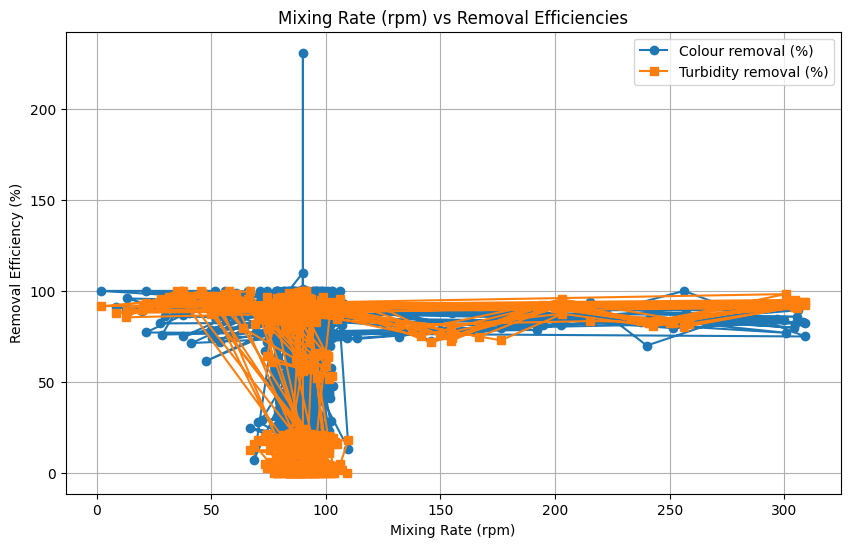

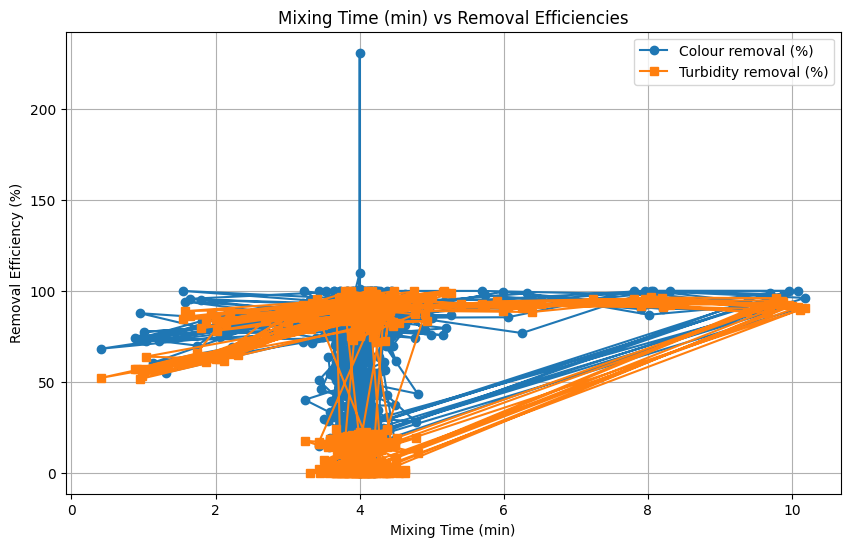

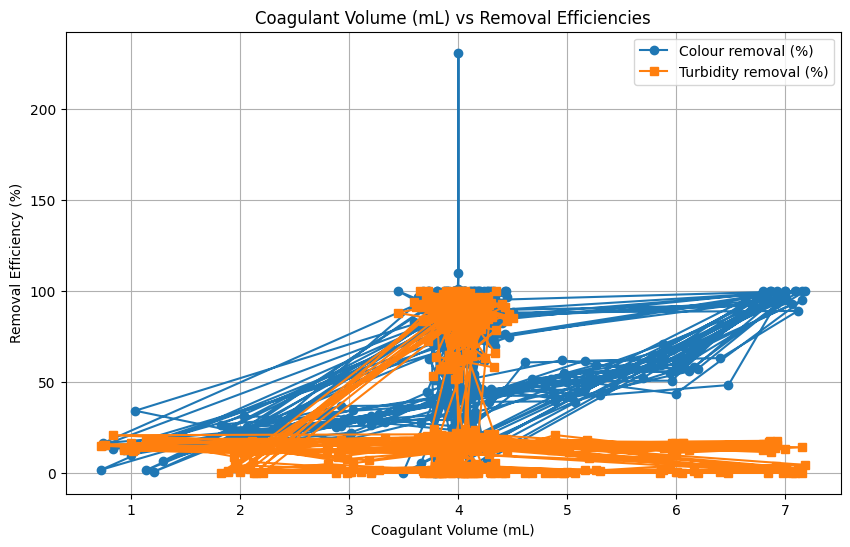

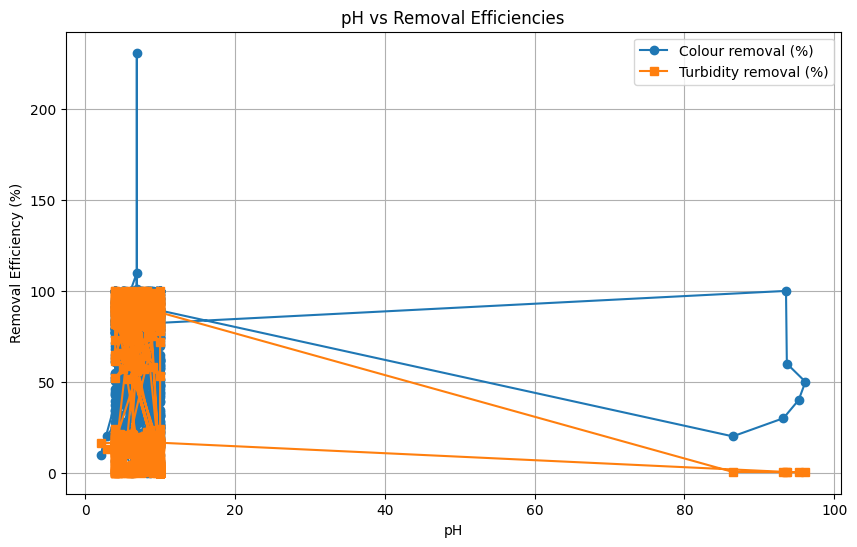

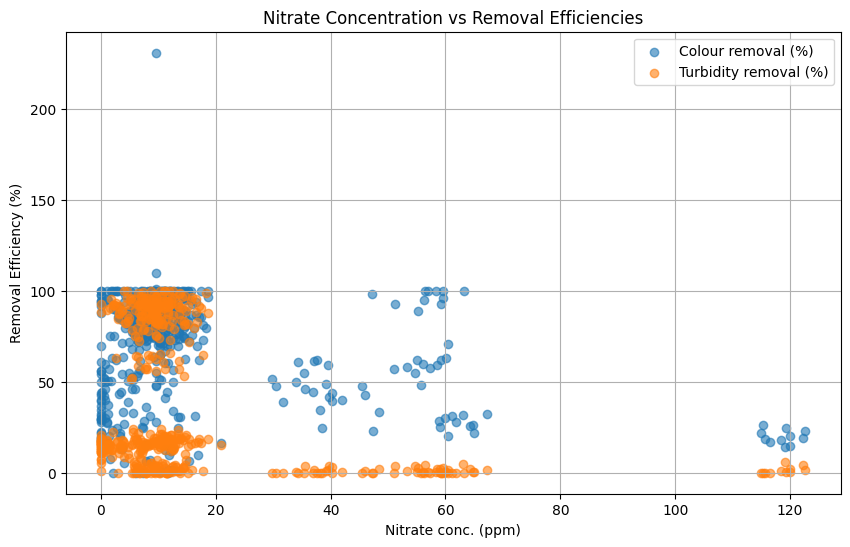

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Load augmented dataset
df = pd.read_csv("augmented_laundry_dataset_final.csv")

# Define plotting functions for clarity

def plot_removal_vs_mixing_rate(df):
    if 'Mixing rate (rpm)' in df and 'Colour removal (%)' in df and 'Turbidity removal (%)' in df:
        plt.figure(figsize=(10,6))
        plt.plot(df['Mixing rate (rpm)'], df['Colour removal (%)'], 'o-', label='Colour removal (%)')
        plt.plot(df['Mixing rate (rpm)'], df['Turbidity removal (%)'], 's-', label='Turbidity removal (%)')
        plt.title('Mixing Rate (rpm) vs Removal Efficiencies')
        plt.xlabel('Mixing Rate (rpm)')
        plt.ylabel('Removal Efficiency (%)')
        plt.grid(True)
        plt.legend()
        plt.show()

def plot_removal_vs_mixing_time(df):
    if 'Mixing time (min)' in df and 'Colour removal (%)' in df and 'Turbidity removal (%)' in df:
        plt.figure(figsize=(10,6))
        plt.plot(df['Mixing time (min)'], df['Colour removal (%)'], 'o-', label='Colour removal (%)')
        plt.plot(df['Mixing time (min)'], df['Turbidity removal (%)'], 's-', label='Turbidity removal (%)')
        plt.title('Mixing Time (min) vs Removal Efficiencies')
        plt.xlabel('Mixing Time (min)')
        plt.ylabel('Removal Efficiency (%)')
        plt.grid(True)
        plt.legend()
        plt.show()

def plot_removal_vs_coagulant_vol(df):
    if 'Coagulant vol.' in df and 'Colour removal (%)' in df and 'Turbidity removal (%)' in df:
        plt.figure(figsize=(10,6))
        plt.plot(df['Coagulant vol.'], df['Colour removal (%)'], 'o-', label='Colour removal (%)')
        plt.plot(df['Coagulant vol.'], df['Turbidity removal (%)'], 's-', label='Turbidity removal (%)')
        plt.title('Coagulant Volume (mL) vs Removal Efficiencies')
        plt.xlabel('Coagulant Volume (mL)')
        plt.ylabel('Removal Efficiency (%)')
        plt.grid(True)
        plt.legend()
        plt.show()

def plot_removal_vs_pH(df):
    # Using 'pH' if present, else 'Initial pH'
    ph_col = None
    if 'pH' in df:
        ph_col = 'pH'
    elif 'Initial pH' in df:
        ph_col = 'Initial pH'

    if ph_col and 'Colour removal (%)' in df and 'Turbidity removal (%)' in df:
        plt.figure(figsize=(10,6))
        plt.plot(df[ph_col], df['Colour removal (%)'], 'o-', label='Colour removal (%)')
        plt.plot(df[ph_col], df['Turbidity removal (%)'], 's-', label='Turbidity removal (%)')
        plt.title(f'{ph_col} vs Removal Efficiencies')
        plt.xlabel(ph_col)
        plt.ylabel('Removal Efficiency (%)')
        plt.grid(True)
        plt.legend()
        plt.show()

def plot_nitrate_vs_removal(df):
    if 'Nitrate conc.(ppm)' in df and 'Colour removal (%)' in df and 'Turbidity removal (%)' in df:
        plt.figure(figsize=(10,6))
        plt.scatter(df['Nitrate conc.(ppm)'], df['Colour removal (%)'], alpha=0.6, label='Colour removal (%)')
        plt.scatter(df['Nitrate conc.(ppm)'], df['Turbidity removal (%)'], alpha=0.6, label='Turbidity removal (%)')
        plt.title('Nitrate Concentration vs Removal Efficiencies')
        plt.xlabel('Nitrate conc. (ppm)')
        plt.ylabel('Removal Efficiency (%)')
        plt.grid(True)
        plt.legend()
        plt.show()

# Call the plotting functions

plot_removal_vs_mixing_rate(df)
plot_removal_vs_mixing_time(df)
plot_removal_vs_coagulant_vol(df)
plot_removal_vs_pH(df)
plot_nitrate_vs_removal(df)
